In [3]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784')
print(mnist)

{'data':        pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
69995       0       0       0       0       0       0       0       0       0   
69996       0       0       0       0       0       0       0       0       0   
69997       0       0       0       0       0       0       0       0       0   
69998       0       0       0       0       0       0       0       0       0   
69999       0       0       0       0       0       0       0       0       0   

       pixel10  ..

(70000, 784)


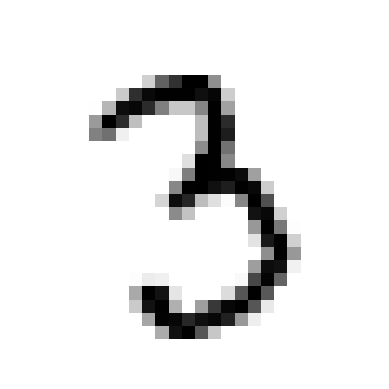

In [61]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
X = mnist["data"]
y = mnist["target"]
print(X.shape)
some_digit = X.iloc[30000].values
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap = matplotlib.cm.binary,
interpolation="nearest")
plt.axis("off")
plt.show()`

In [63]:
# create test set and set it aside 
import numpy as np
import pandas as pd
X_train, X_test, y_train, y_test = X.iloc[:60000], X.iloc[60000:], y.iloc[:60000], y.iloc[60000:]
shuffle_index = np.random.permutation(len(X_train))
X_train, y_train = X_train.iloc[shuffle_index], y_train.iloc[shuffle_index]

In [64]:
y_train_3 = (y_train.astype(int) == 3)
y_test_3 = (y_test.astype(int) == 3)

In [70]:
# train the model
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_3)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [68]:
# predict using the model
some_digit = some_digit.reshape(1, -1)
some_digit_df = pd.DataFrame(some_digit, columns=X_train.columns)
prediction = sgd_clf.predict(some_digit_df)
print(prediction)

[ True]


In [78]:
# Implementing Cross-Validation
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
for train_index, test_index in skfolds.split(X_train, y_train_3):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train.iloc[train_index]
    y_train_folds = y_train_3.iloc[train_index]
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train_3.iloc[test_index]
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred)) # prints 0.9502, 0.96565 and 0.96495

0.9678
0.96175
0.961


In [76]:
# using cross_val_score function
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_3, cv=3, scoring="accuracy")

array([0.9515, 0.9632, 0.9646])

In [81]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_3, cv=3)

In [82]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_3, y_train_pred)

array([[52305,  1564],
       [  850,  5281]])

In [87]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_3, y_train_pred) # == 4344 / (4344 + 1307)

0.7715120525931337

In [88]:
recall_score(y_train_3, y_train_pred) # == 4344 / (4344 + 1077)

0.8613603001141739